# Decision Tree Classification
### Definition
Decision tree algorithms use a tree of inequalities to classify data by maximizing the amount of information gain with the inequality among the features.

### Algorithm
The decision tree algorithm used for classification is a part of CART (classification and regression trees). 
1. First, we select the split that minimizes the Gini impurity of all child nodes, which measures how likely it is to incorrectly label an element based on the subset of elements that reach the given node.
2. Then, create child nodes based on the split.
3. Repeat for all child nodes until either a max depth is reached or the gini impurity is sufficiently small (so classification is good)

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, mean_squared_error

import struct

sns.set_theme()

# Data

We will load in the Titanic data that we created in the preprocessing step:

In [24]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/Titanic-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
PCA_train_X = np.load(f"{data_dir}/PCA_train_X.npy")
PCA_train_y = np.load(f"{data_dir}/PCA_train_y.npy")
PCA_test_X = np.load(f"{data_dir}/PCA_test_X.npy")
PCA_test_y = np.load(f"{data_dir}/PCA_test_y.npy")
train_X

array([[ 3.,  0., 22., ...,  1.,  0.,  0.],
       [ 1.,  1., 38., ...,  0.,  1.,  0.],
       [ 3.,  1., 26., ...,  0.,  1.,  0.],
       ...,
       [ 3.,  0., 27., ...,  1.,  0.,  0.],
       [ 1.,  0., 42., ...,  1.,  0.,  0.],
       [ 3.,  0., 20., ...,  1.,  0.,  0.]], shape=(622, 14))

## PCA Data Analysis
First, train the decision tree classifier:

In [25]:
tree = DecisionTreeClassifier(max_depth = 3)
tree.fit(PCA_train_X, PCA_train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Now, display the tree in a few ways:

In [26]:
print(export_text(tree, feature_names=["PC1", "PC2"]))

|--- PC2 <= 0.00
|   |--- PC2 <= -1.39
|   |   |--- PC2 <= -2.58
|   |   |   |--- class: 1
|   |   |--- PC2 >  -2.58
|   |   |   |--- class: 0
|   |--- PC2 >  -1.39
|   |   |--- PC2 <= -0.29
|   |   |   |--- class: 1
|   |   |--- PC2 >  -0.29
|   |   |   |--- class: 1
|--- PC2 >  0.00
|   |--- PC2 <= 0.41
|   |   |--- PC2 <= 0.40
|   |   |   |--- class: 0
|   |   |--- PC2 >  0.40
|   |   |   |--- class: 1
|   |--- PC2 >  0.41
|   |   |--- PC1 <= -1.27
|   |   |   |--- class: 0
|   |   |--- PC1 >  -1.27
|   |   |   |--- class: 0



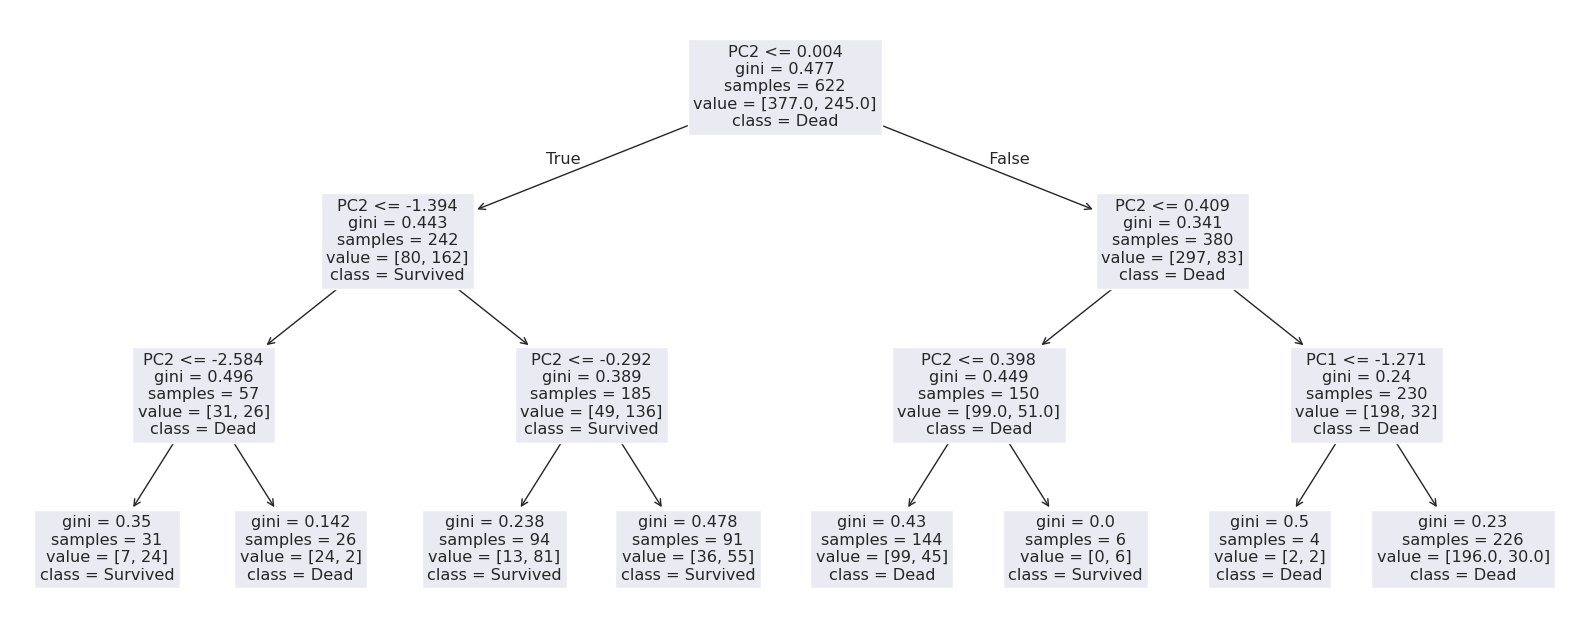

In [27]:
plt.figure(figsize=(20, 8))
plot_tree(tree, feature_names=["PC1", "PC2"], class_names=["Dead", "Survived"])
plt.show()

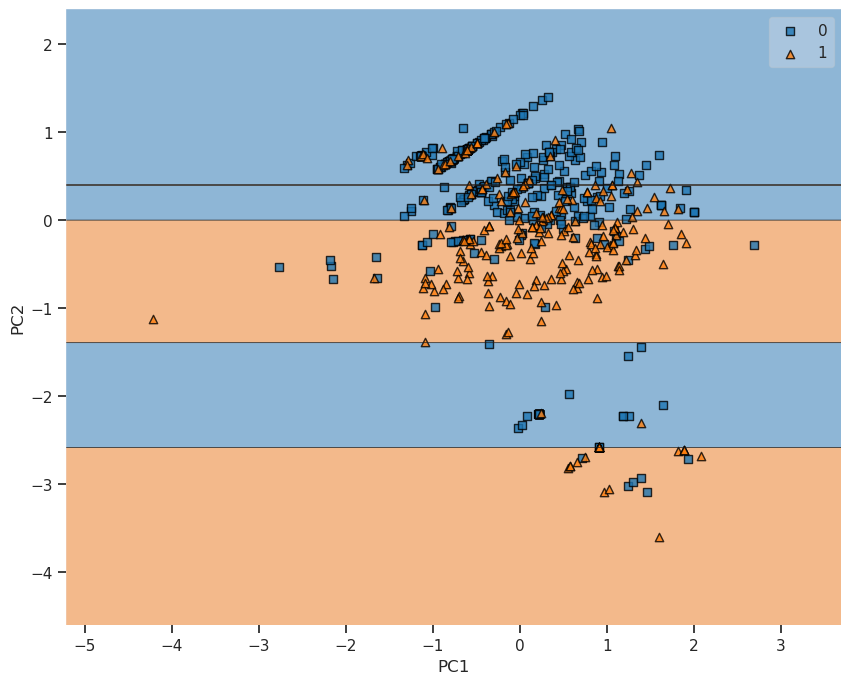

In [28]:
plt.figure(figsize = (10, 8))
plot_decision_regions(PCA_train_X, PCA_train_y.astype(np.int32), clf = tree)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()


Showing confusion matrix:

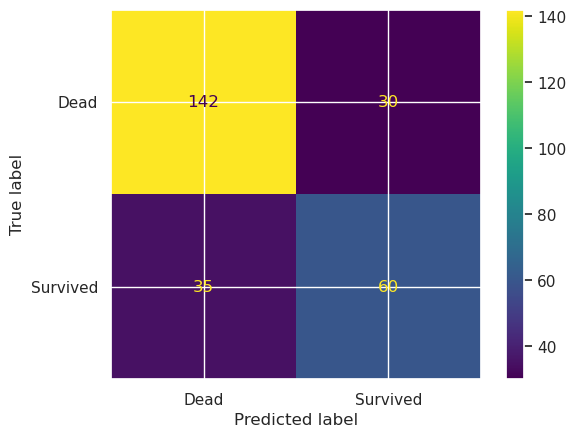

In [32]:
test_predictions = tree.predict(PCA_test_X)
conf_mat = confusion_matrix(PCA_test_y, test_predictions)
conf_mat_display = ConfusionMatrixDisplay(conf_mat, display_labels=["Dead", "Survived"])
conf_mat_display.plot()
plt.show()


Now show classification error:

In [37]:
conf_df = pd.DataFrame(conf_mat, dtype=np.int32)
accurate_count = conf_df.iloc[0, 0] + conf_df.iloc[1, 1]
inaccurate_count = conf_df.iloc[1, 0] + conf_df.iloc[0, 1]
percent_accurate = accurate_count / (accurate_count + inaccurate_count)
print(f"Percent accurate predictions: {percent_accurate*100.0: 3.2f}%")
print(f"{accurate_count} predicted accurately out of {accurate_count + inaccurate_count}")


Percent accurate predictions:  75.66%
202 predicted accurately out of 267


Now, we will display the classification error of various depths of the decision tree:

In [40]:
depths = [1, 2, 3, 4, 5, 8, 15, 25, 40]
classification_accuracies = []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth = depth)
    tree.fit(PCA_train_X, PCA_train_y)
    test_predictions = tree.predict(PCA_test_X)
    conf_mat = confusion_matrix(PCA_test_y, test_predictions)

    conf_df = pd.DataFrame(conf_mat, dtype=np.int32)
    accurate_count = conf_df.iloc[0, 0] + conf_df.iloc[1, 1]
    inaccurate_count = conf_df.iloc[1, 0] + conf_df.iloc[0, 1]
    percent_accurate = accurate_count / (accurate_count + inaccurate_count)
    classification_accuracies.append(percent_accurate)

In [41]:
for (j, acc) in enumerate(classification_accuracies):
    print(f"Depth {depths[j]:2d}: Accuracy {acc*100.0: 2.3f}%")

Depth  1: Accuracy  72.285%
Depth  2: Accuracy  77.154%
Depth  3: Accuracy  75.655%
Depth  4: Accuracy  74.532%
Depth  5: Accuracy  75.655%
Depth  8: Accuracy  74.157%
Depth 15: Accuracy  68.539%
Depth 25: Accuracy  67.790%
Depth 40: Accuracy  69.288%


Thus, we can see that decision trees of depth 2 model the PCA data best.

## Full Dimension Data Analysis

In [42]:
depths = [1, 2, 3, 4, 5, 8, 15, 25, 40]
classification_accuracies = []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth = depth)
    tree.fit(train_X, train_y)
    test_predictions = tree.predict(test_X)
    conf_mat = confusion_matrix(test_y, test_predictions)

    conf_df = pd.DataFrame(conf_mat, dtype=np.int32)
    accurate_count = conf_df.iloc[0, 0] + conf_df.iloc[1, 1]
    inaccurate_count = conf_df.iloc[1, 0] + conf_df.iloc[0, 1]
    percent_accurate = accurate_count / (accurate_count + inaccurate_count)
    classification_accuracies.append(percent_accurate)

In [43]:
for (j, acc) in enumerate(classification_accuracies):
    print(f"Depth {depths[j]:2d}: Accuracy {acc*100.0: 2.3f}%")

Depth  1: Accuracy  78.277%
Depth  2: Accuracy  81.273%
Depth  3: Accuracy  83.895%
Depth  4: Accuracy  78.652%
Depth  5: Accuracy  81.648%
Depth  8: Accuracy  78.277%
Depth 15: Accuracy  79.026%
Depth 25: Accuracy  76.030%
Depth 40: Accuracy  76.779%


Thus, we can see that decision trees of depth 3 model the full-dimension data best.